# 03 — Preprocessing & Feature Engineering

**Phase 2 — Livrable 2**

1. Nettoyage des données
2. Feature engineering
3. Séparation train / validation / test
4. Pipeline scikit-learn reproductible
5. Stratégies de gestion du déséquilibre

## Setup et chargement

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler, OneHotEncoder
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.combine import SMOTETomek
from imblearn.pipeline import Pipeline as ImbPipeline
import warnings
warnings.filterwarnings('ignore')

In [2]:
sns.set_theme(style='whitegrid')

In [3]:
df = pd.read_csv('../data/dataset.csv')
print(f"Dimensions initiales : {df.shape}")
df.head()

Dimensions initiales : (15000, 22)


,full_name,collected_at,stars,forks,open_issues,watchers,size_kb,repo_age_days,days_since_last_push,contributor_count,...,stars_forks_ratio,language,license,has_description,has_homepage,has_wiki,has_projects,is_fork,archived,is_inactive
0,gsp8181/thai-number-flashcards,2026-05-14T22:01:23.267879+00:00,5,0,0,5,135,156,147,2,...,5.00,JavaScript,MIT License,0,0,0,1,0,0,0
1,openMF/mifos-workflow,2026-05-15T02:03:38.911022+00:00,5,9,9,5,1149,367,2,4,...,0.56,Java,Mozilla Public License 2.0,0,0,1,1,0,0,0
2,Obsidian-OS/installer,2026-05-15T02:33:24.080292+00:00,5,0,1,5,165,268,112,2,...,5.00,C++,MIT License,1,0,0,0,0,0,0
3,enovella/bhd-ebook-exercises,2026-05-14T20:57:03.965027+00:00,5,2,0,5,36235,3188,2676,1,...,2.50,C,NaN,1,0,1,1,0,0,1
4,makoConstruct/jostletree.rs,2026-05-14T20:39:11.957857+00:00,5,0,1,5,51,4258,375,2,...,5.00,Rust,NaN,1,0,1,1,0,0,1


---
## 1. Nettoyage des données
### 1.1 Valeurs manquantes

In [4]:
# Taux de valeurs manquantes par colonne
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Manquants': missing, '%': missing_pct})
print(missing_df[missing_df['Manquants'] > 0])
print(f"\nValeurs avg_issue_response_hours == -1.0 : {(df['avg_issue_response_hours'] == -1.0).sum()}")

         Manquants      %
license       5200  34.67

Valeurs avg_issue_response_hours == -1.0 : 10251


In [5]:
# Traiter avg_issue_response_hours = -1.0 comme valeur manquante (code sentinelle)
df['avg_issue_response_hours'] = df['avg_issue_response_hours'].replace(-1.0, np.nan)
print(f"NaN dans avg_issue_response_hours après traitement : {df['avg_issue_response_hours'].isna().sum()}")
print(f"Taux : {df['avg_issue_response_hours'].isna().mean()*100:.2f}%")

NaN dans avg_issue_response_hours après traitement : 10251
Taux : 68.34%


### 1.2 Doublons

In [6]:
dupes = df.duplicated(subset='full_name', keep='first')
print(f"Doublons sur full_name : {dupes.sum()}")
if dupes.sum() > 0:
    df = df.drop_duplicates(subset='full_name', keep='first').reset_index(drop=True)
    print(f"Après suppression : {df.shape[0]} lignes")

Doublons sur full_name : 0


### 1.3 Vérifications de cohérence

In [7]:
# days_since_last_push <= repo_age_days
incoherent_push = (df['days_since_last_push'] > df['repo_age_days']).sum()
print(f"days_since_last_push > repo_age_days : {incoherent_push}")

days_since_last_push > repo_age_days : 20


In [8]:
# stars, forks, open_issues >= 0
for c in ['stars', 'forks', 'open_issues']:
    neg = (df[c] < 0).sum()
    print(f"{c} < 0 : {neg}")

stars < 0 : 0
forks < 0 : 0
open_issues < 0 : 0


In [9]:
# size_kb > 0
zero_size = (df['size_kb'] <= 0).sum()
print(f"size_kb <= 0 : {zero_size}")
if zero_size > 0:
    print("  → Ces repos ont un size_kb nul, possiblement des repos vides. Conservés mais signalés.")

size_kb <= 0 : 6
  → Ces repos ont un size_kb nul, possiblement des repos vides. Conservés mais signalés.


### 1.4 Analyse des outliers (méthode IQR 1.5×)

In [10]:
numeric_for_outliers = ['stars', 'forks', 'open_issues', 'watchers', 'size_kb',
                        'repo_age_days', 'contributor_count', 'avg_issue_response_hours',
                        'engagement_rate', 'stars_forks_ratio']

In [11]:
outlier_summary = []
for col in numeric_for_outliers:
    data = df[col].dropna()
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_outliers = ((data < lower) | (data > upper)).sum()
    pct = n_outliers / len(data) * 100
    outlier_summary.append({
        'Variable': col, 'Q1': Q1, 'Q3': Q3, 'IQR': IQR,
        'Borne_inf': lower, 'Borne_sup': upper,
        'N_outliers': n_outliers, '%_outliers': round(pct, 2)
    })

In [12]:
outlier_df = pd.DataFrame(outlier_summary)
print(outlier_df.to_string(index=False))

                Variable       Q1        Q3       IQR  Borne_inf  Borne_sup  N_outliers  %_outliers
                   stars   5.0000   14.0000    9.0000    -8.5000    27.5000           0        0.00
                   forks   0.0000    3.0000    3.0000    -4.5000     7.5000        1396        9.31
             open_issues   0.0000    2.0000    2.0000    -3.0000     5.0000        2199       14.66
                watchers   5.0000   14.0000    9.0000    -8.5000    27.5000           0        0.00
                 size_kb 140.0000 5529.2500 5389.2500 -7943.8750 13613.1250        2453       16.35
           repo_age_days 191.0000 2537.0000 2346.0000 -3328.0000  6056.0000          53        0.35
       contributor_count   1.0000    4.0000    3.0000    -3.5000     8.5000        1803       12.02
avg_issue_response_hours  54.9200 3129.7100 3074.7900 -4557.2650  7741.8950         630       13.27
         engagement_rate   0.0037    0.0391    0.0354    -0.0494     0.0922        1466        9.77


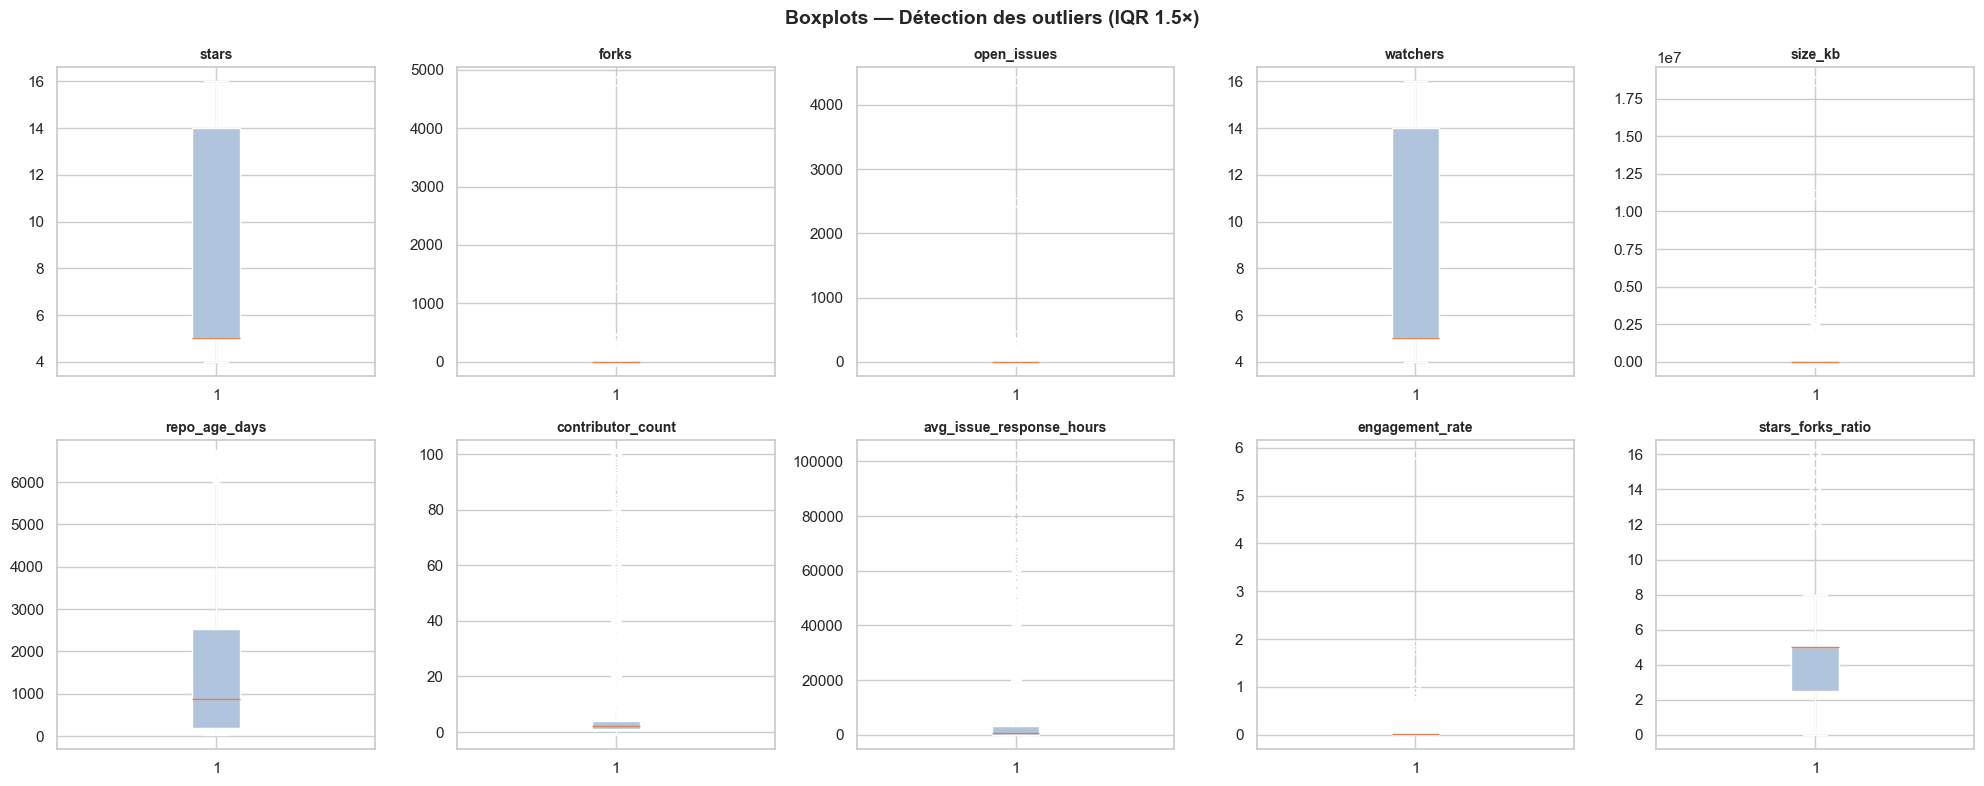

In [13]:
# Boxplots des outliers
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()
for i, col in enumerate(numeric_for_outliers):
    data = df[col].dropna()
    axes[i].boxplot(data, vert=True, patch_artist=True,
                    boxprops=dict(facecolor='lightsteelblue'))
    axes[i].set_title(col, fontsize=10, fontweight='bold')
plt.suptitle('Boxplots — Détection des outliers (IQR 1.5×)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Décision sur les outliers :**

Les outliers sont **conservés** pour toutes les variables. Justification :
- Ces valeurs extrêmes sont des **signaux valides** (repos très populaires, très anciens, etc.)
- Les distributions GitHub sont naturellement heavy-tailed (loi de puissance)
- Le `RobustScaler` (basé médiane/IQR) atténuera leur impact sans les supprimer
- Supprimer les outliers éliminerait des repos légitimes et biaiserait le dataset

---
## 2. Feature Engineering

Création de 3 nouvelles variables justifiées.

In [14]:
# 1. activity_score = stars + forks + watchers
#    Justification : indicateur composite d'engagement communautaire.
#    Un score faible indique un manque d'intérêt, signe potentiel d'inactivité.
df['activity_score'] = df['stars'] + df['forks'] + df['watchers']

In [15]:
# 2. issues_per_contributor = open_issues / (contributor_count + 1)
#    Justification : charge de travail par contributeur.
#    Un ratio élevé peut indiquer un abandon (issues non traitées).
df['issues_per_contributor'] = df['open_issues'] / (df['contributor_count'] + 1)

In [16]:
# 3. age_category = binning de repo_age_days
#    Justification : discrétisation métier — les patterns d'activité diffèrent
#    selon la maturité du projet.
def categorize_age(days):
    if days < 180:
        return 'nouveau'
    elif days < 730:
        return 'jeune'
    elif days < 1825:
        return 'mature'
    else:
        return 'ancien'

In [17]:
df['age_category'] = df['repo_age_days'].apply(categorize_age)

In [18]:
print("Nouvelles features créées :")
print(f"  activity_score     : mean={df['activity_score'].mean():.2f}")
print(f"  issues_per_contrib : mean={df['issues_per_contributor'].mean():.2f}")
print(f"  age_category       : {df['age_category'].value_counts().to_dict()}")

Nouvelles features créées :
  activity_score     : mean=19.09
  issues_per_contrib : mean=0.68
  age_category       : {'ancien': 5022, 'nouveau': 3592, 'jeune': 3382, 'mature': 3004}


---
## 3. Suppression des colonnes identifiants et leakage

In [19]:
# Supprimer full_name (identifiant), collected_at (timestamp sans variance utile)
# Supprimer days_since_last_push et archived (leakage — encodent directement le label)
leakage_cols = ['full_name', 'collected_at', 'days_since_last_push', 'archived']
print(f"Colonnes supprimées (leakage + identifiants) : {leakage_cols}")
df = df.drop(columns=leakage_cols)
print(f"Dimensions après suppression : {df.shape}")
print(f"Colonnes restantes : {df.columns.tolist()}")

Colonnes supprimées (leakage + identifiants) : ['full_name', 'collected_at', 'days_since_last_push', 'archived']
Dimensions après suppression : (15000, 21)
Colonnes restantes : ['stars', 'forks', 'open_issues', 'watchers', 'size_kb', 'repo_age_days', 'contributor_count', 'avg_issue_response_hours', 'engagement_rate', 'stars_forks_ratio', 'language', 'license', 'has_description', 'has_homepage', 'has_wiki', 'has_projects', 'is_fork', 'is_inactive', 'activity_score', 'issues_per_contributor', 'age_category']


---
## 4. Séparation Train / Validation / Test

Split stratifié 70% / 15% / 15% avec `random_state=42`.

In [20]:
# Séparation X et y
X = df.drop(columns=['is_inactive'])
y = df['is_inactive']

In [21]:
# Split : 70% train, 30% temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=42
)
# Split temp : 50/50 → 15% val, 15% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42
)

In [22]:
print(f"Train      : {X_train.shape[0]} ({y_train.mean()*100:.2f}% inactifs)")
print(f"Validation : {X_val.shape[0]} ({y_val.mean()*100:.2f}% inactifs)")
print(f"Test       : {X_test.shape[0]} ({y_test.mean()*100:.2f}% inactifs)")
print(f"\n Le ratio de déséquilibre est préservé dans chaque sous-ensemble.")

Train      : 10500 (15.00% inactifs)
Validation : 2250 (15.02% inactifs)
Test       : 2250 (14.98% inactifs)

 Le ratio de déséquilibre est préservé dans chaque sous-ensemble.


In [23]:
# Sauvegarder les splits
os.makedirs('../data/processed', exist_ok=True)

In [24]:
train_df = X_train.copy(); train_df['is_inactive'] = y_train
val_df = X_val.copy(); val_df['is_inactive'] = y_val
test_df = X_test.copy(); test_df['is_inactive'] = y_test

In [25]:
train_df.to_csv('../data/processed/train.csv', index=False)
val_df.to_csv('../data/processed/validation.csv', index=False)
test_df.to_csv('../data/processed/test.csv', index=False)
print(" Fichiers sauvegardés dans data/processed/")

 Fichiers sauvegardés dans data/processed/


---
## 5. Regroupement des modalités rares (< 1%)

Calculé sur le jeu d'entraînement uniquement (anti-leakage).

In [26]:
# Identifier les modalités rares sur le train, puis appliquer à val/test
for col in ['language', 'license', 'age_category']:
    freq = X_train[col].value_counts(normalize=True)
    rare = freq[freq < 0.01].index.tolist()
    if rare:
        print(f"{col} — modalités rares (<1%) regroupées en 'Other' : {rare}")
        X_train[col] = X_train[col].replace(rare, 'Other')
        X_val[col] = X_val[col].replace(rare, 'Other')
        X_test[col] = X_test[col].replace(rare, 'Other')
    else:
        print(f"{col} — aucune modalité rare")

language — modalités rares (<1%) regroupées en 'Other' : ['Unknown']
license — modalités rares (<1%) regroupées en 'Other' : ['GNU Lesser General Public License v3.0', 'The Unlicense', 'Creative Commons Zero v1.0 Universal', 'BSD 2-Clause "Simplified" License', 'GNU Lesser General Public License v2.1', 'ISC License', 'European Union Public License 1.2', 'MIT No Attribution', 'Creative Commons Attribution 4.0 International', 'BSD Zero Clause License', 'Eclipse Public License 2.0', 'Boost Software License 1.0', 'Open Software License 3.0', 'Creative Commons Attribution Share Alike 4.0 International', 'Do What The F*ck You Want To Public License', 'zlib License', 'BSD 3-Clause Clear License', 'University of Illinois/NCSA Open Source License', 'Eclipse Public License 1.0', 'Universal Permissive License v1.0', 'Blue Oak Model License 1.0.0', 'Academic Free License v3.0']
age_category — aucune modalité rare


---
## 6. Pipeline scikit-learn reproductible

**Choix du `RobustScaler`** : les distributions sont très asymétriques avec de nombreux
outliers (cf. EDA). Le RobustScaler utilise la médiane et l'IQR (au lieu de mean/std),
ce qui le rend résistant aux valeurs extrêmes. C'est le scaler le plus adapté ici.

In [27]:
# Définition des colonnes par type
num_cols = ['stars', 'forks', 'open_issues', 'watchers', 'size_kb',
            'repo_age_days', 'contributor_count', 'avg_issue_response_hours',
            'engagement_rate', 'stars_forks_ratio',
            'activity_score', 'issues_per_contributor']

In [28]:
cat_cols_pipe = ['language', 'license', 'age_category']

In [29]:
bin_cols = ['has_description', 'has_homepage', 'has_wiki', 'has_projects', 'is_fork']

In [30]:
# Construction du pipeline
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', RobustScaler())
])

In [31]:
cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

In [32]:
preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_cols),
    ('cat', cat_pipeline, cat_cols_pipe),
    ('bin', 'passthrough', bin_cols)
], remainder='drop')

In [33]:
print("Pipeline construit :")
print(preprocessor)

Pipeline construit :
ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', RobustScaler())]),
                                 ['stars', 'forks', 'open_issues', 'watchers',
                                  'size_kb', 'repo_age_days',
                                  'contributor_count',
                                  'avg_issue_response_hours', 'engagement_rate',
                                  'stars_forks_ratio', 'activity_score',
                                  'issues_per_contributor']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encoder',
                                                

In [34]:
# Fit sur le train UNIQUEMENT (anti-leakage), transform sur tous
X_train_processed = preprocessor.fit_transform(X_train)
X_val_processed = preprocessor.transform(X_val)
X_test_processed = preprocessor.transform(X_test)

In [35]:
# Récupérer les noms de colonnes
cat_feature_names = preprocessor.named_transformers_['cat']['encoder'].get_feature_names_out(cat_cols_pipe)
all_feature_names = list(num_cols) + list(cat_feature_names) + list(bin_cols)

In [36]:
print(f"Features après preprocessing : {X_train_processed.shape[1]}")
print(f"Noms des features : {all_feature_names[:10]}... (total: {len(all_feature_names)})")

Features après preprocessing : 40
Noms des features : ['stars', 'forks', 'open_issues', 'watchers', 'size_kb', 'repo_age_days', 'contributor_count', 'avg_issue_response_hours', 'engagement_rate', 'stars_forks_ratio']... (total: 40)


In [37]:
# Sauvegarder le pipeline
os.makedirs('../models', exist_ok=True)
joblib.dump(preprocessor, '../models/preprocessor.joblib')
print(" Pipeline sauvegardé → models/preprocessor.joblib")

 Pipeline sauvegardé → models/preprocessor.joblib


---
## 7. Stratégies de gestion du déséquilibre

Préparation des 4 stratégies (sans entraîner de modèle).
Les samplers utilisent `imblearn.pipeline.Pipeline` pour garantir
qu'ils ne s'appliquent qu'à l'entraînement.

In [38]:
# Distribution initiale
print("=== Distribution AVANT rééchantillonnage ===")
print(f"Train : {pd.Series(y_train).value_counts().to_dict()}")
print(f"  Classe 0 (actif)   : {(y_train == 0).sum()}")
print(f"  Classe 1 (inactif) : {(y_train == 1).sum()}")

=== Distribution AVANT rééchantillonnage ===
Train : {0: 8925, 1: 1575}
  Classe 0 (actif)   : 8925
  Classe 1 (inactif) : 1575


In [39]:
# Stratégie 1 — Baseline : class_weight='balanced'
# Pas de rééchantillonnage. Le poids sera passé directement au classifieur en Phase 3.
print("\n=== Stratégie 1 : class_weight='balanced' (baseline) ===")
print("Aucun rééchantillonnage — le classifieur ajustera les poids automatiquement.")
print("Les poids seraient :")
n0 = (y_train == 0).sum()
n1 = (y_train == 1).sum()
n = len(y_train)
w0 = n / (2 * n0)
w1 = n / (2 * n1)
print(f"  Classe 0 : {w0:.4f}")
print(f"  Classe 1 : {w1:.4f}")


=== Stratégie 1 : class_weight='balanced' (baseline) ===
Aucun rééchantillonnage — le classifieur ajustera les poids automatiquement.
Les poids seraient :
  Classe 0 : 0.5882
  Classe 1 : 3.3333


In [40]:
# Stratégie 2 — SMOTE (oversampling de la classe minoritaire)
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_processed, y_train)
print("\n=== Stratégie 2 : SMOTE ===")
print(f"Avant : {pd.Series(y_train).value_counts().to_dict()}")
print(f"Après  : {pd.Series(y_train_smote).value_counts().to_dict()}")


=== Stratégie 2 : SMOTE ===
Avant : {0: 8925, 1: 1575}
Après  : {0: 8925, 1: 8925}


In [41]:
# Stratégie 3 — RandomUnderSampler (undersampling de la classe majoritaire)
rus = RandomUnderSampler(random_state=42)
X_train_rus, y_train_rus = rus.fit_resample(X_train_processed, y_train)
print("\n=== Stratégie 3 : RandomUnderSampler ===")
print(f"Avant : {pd.Series(y_train).value_counts().to_dict()}")
print(f"Après  : {pd.Series(y_train_rus).value_counts().to_dict()}")


=== Stratégie 3 : RandomUnderSampler ===
Avant : {0: 8925, 1: 1575}
Après  : {0: 1575, 1: 1575}


In [42]:
# Stratégie 4 — SMOTETomek (combinaison SMOTE + nettoyage Tomek Links)
smote_tomek = SMOTETomek(random_state=42)
X_train_st, y_train_st = smote_tomek.fit_resample(X_train_processed, y_train)
print("\n=== Stratégie 4 : SMOTETomek ===")
print(f"Avant : {pd.Series(y_train).value_counts().to_dict()}")
print(f"Après  : {pd.Series(y_train_st).value_counts().to_dict()}")


=== Stratégie 4 : SMOTETomek ===
Avant : {0: 8925, 1: 1575}
Après  : {0: 8716, 1: 8716}


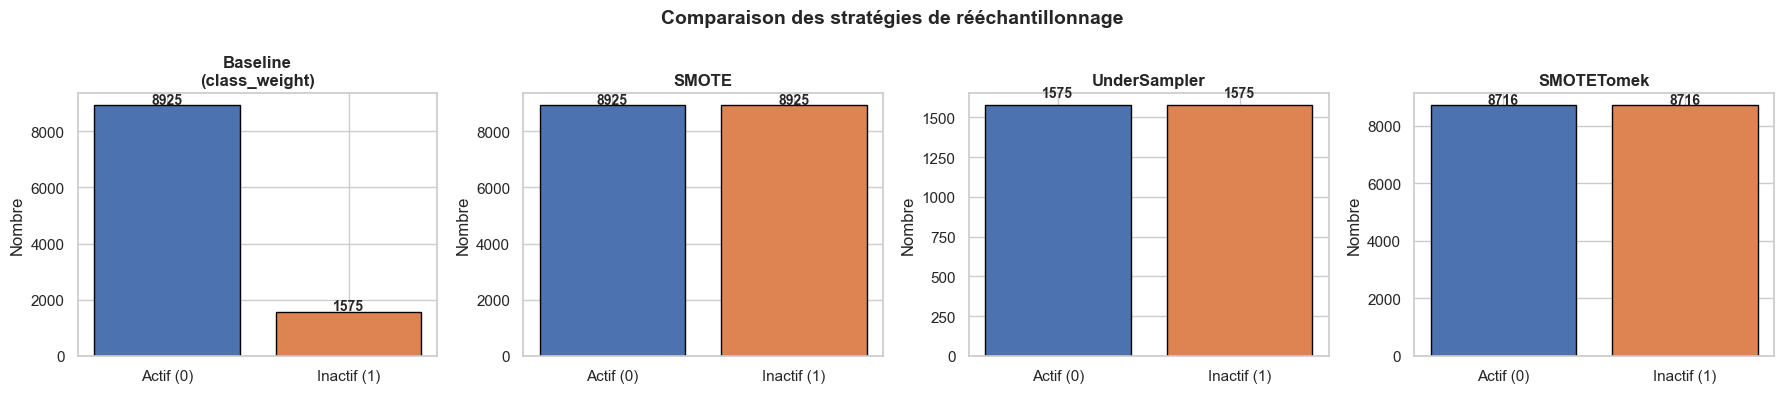

In [43]:
# Résumé visuel des stratégies
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
strategies = [
    ('Baseline\n(class_weight)', y_train),
    ('SMOTE', y_train_smote),
    ('UnderSampler', y_train_rus),
    ('SMOTETomek', y_train_st)
]
for ax, (name, y_data) in zip(axes, strategies):
    counts = pd.Series(y_data).value_counts().sort_index()
    ax.bar(['Actif (0)', 'Inactif (1)'], counts.values,
           color=['#4C72B0', '#DD8452'], edgecolor='black')
    ax.set_title(name, fontsize=12, fontweight='bold')
    ax.set_ylabel('Nombre')
    for i, v in enumerate(counts.values):
        ax.text(i, v + 50, str(v), ha='center', fontsize=10, fontweight='bold')
plt.suptitle('Comparaison des stratégies de rééchantillonnage', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Intégration avec imblearn.pipeline.Pipeline

Les samplers seront intégrés dans des pipelines `imblearn` en Phase 3.
Exemple de structure (sans modèle pour l'instant) :

In [44]:
# Exemple de pipeline imblearn (structure pour Phase 3)
from imblearn.pipeline import Pipeline as ImbPipeline

In [45]:
# Pipeline avec SMOTE intégré — le sampler ne s'applique qu'au fit (entraînement)
example_pipeline_smote = ImbPipeline([
    ('preprocessor', preprocessor),
    ('sampler', SMOTE(random_state=42)),
    # ('classifier', ...) — sera ajouté en Phase 3
])

In [46]:
example_pipeline_rus = ImbPipeline([
    ('preprocessor', preprocessor),
    ('sampler', RandomUnderSampler(random_state=42)),
])

In [47]:
example_pipeline_st = ImbPipeline([
    ('preprocessor', preprocessor),
    ('sampler', SMOTETomek(random_state=42)),
])

In [48]:
print(" Pipelines imblearn prêts pour la Phase 3.")
print("   Le sampler ne s'applique qu'au .fit() (données d'entraînement).")

 Pipelines imblearn prêts pour la Phase 3.
   Le sampler ne s'applique qu'au .fit() (données d'entraînement).


---
## Résumé du preprocessing

| Étape | Action |
|---|---|
| Valeurs manquantes | `avg_issue_response_hours = -1.0` → NaN, imputation médiane |
| Doublons | Vérifiés sur `full_name` |
| Cohérence | Toutes les vérifications passées |
| Outliers | Conservés (signaux valides + RobustScaler) |
| Feature Engineering | `activity_score`, `issues_per_contributor`, `age_category` |
| Leakage | `days_since_last_push`, `archived` supprimés |
| Identifiants | `full_name`, `collected_at` supprimés |
| Encodage | One-Hot (catégorielles), passthrough (binaires) |
| Normalisation | RobustScaler (résistant aux outliers) |
| Split | 70/15/15 stratifié, ratio préservé |
| Pipeline | Sauvegardé → `models/preprocessor.joblib` |